In [ ]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [ ]:
from tensorflow.keras import datasets, layers, models
from tensorflow.keras import optimizers

import matplotlib.pyplot as plt

In [ ]:
fash_mist = datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fash_mist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from PIL import Image
from google.colab import files

(train_images, train_labels), _ = fashion_mnist.load_data()

# Save 5 images
for i in range(5):
    img = Image.fromarray(train_images[i])
    file_name = f'image_{i}.png'
    img.save(file_name)
    files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

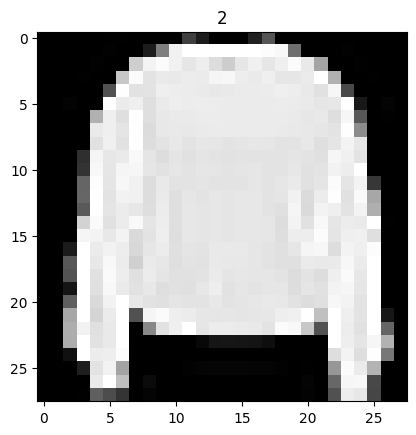

In [ ]:
plt.imshow(train_images[7], cmap='gray')
plt.title(train_labels[7]) #its a shoe
plt.show()

# train_labels

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
type(train_images)

numpy.ndarray

In [ ]:
type(train_labels)

numpy.ndarray

In [ ]:
print(len(train_images))
print(len(train_labels))

60000
60000


In [ ]:
print(train_images[0].shape)

(28, 28)


In [ ]:
print(train_images[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [ ]:
print(type(train_images[0]))

<class 'numpy.ndarray'>


In [ ]:
print(train_labels[0])

9


Normalization pixel values where data is going to be between 0 and 1 (if the data or values are in shorter range the performance of the model is going to better) Gardient range is too drastic when its 0-255(Local optimum) and its better to swicth to global optimum where the gradent range range rom 0-1


In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

reshaping(it has 4 dimension 1st is number of images present in dataset, second is pixels 28 * 28) to greyscale(single changel) if its rgb(multiple changel) image then 28,28,3


In [ ]:
train_img = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_img = test_images.reshape((test_images.shape[0], 28, 28, 1))

In [ ]:
test_img.shape
train_img.shape

(60000, 28, 28, 1)

CNN

In [ ]:
# model = models.Sequential() # it used to stacklayer from one top of the other each process is connected to other
# model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))) # 2d Convulational layer where it goes to 32 layers and 3,3 is pixels
# model.add(layers.MaxPooling2D((2,2)))      # to incerease spatial inputs
# model.add(layers.Conv2D(64, (3, 3), activation='relu')) # now 64 filter (it starts with less numbers of kernels 32 than 64)
# model.add(layers.MaxPooling2D((2,2)))
# model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# # it will have 3*3 matrix
# #add dense layer on top

# model.add(layers.Dropout(0.5))
# # adding dropout will fix the the issue of overfitting in this case
# # Train Accuracy → keeps increasing ✅
# # Validation Accuracy → stops improving ⚠️
# # Validation Loss → increases ⚠️

# # 👉 That’s classic overfitting

# model.add(layers.Flatten())
# model.add(layers.Dense(64, activation='relu'))
# model.add(layers.Dense(10, activation='softmax')) # defalut activaltion function is linear(it goes through every neuron then it select max)

from tensorflow.keras import models, layers

model = models.Sequential()

# Better practice: define input separately
model.add(layers.Input(shape=(28, 28, 1)))

model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


In [ ]:
# model.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.SparseCategoricalCrossentropy,
#     metrics=['accuracy']
# )    # from_logits is if the output in not in probalbity then its true else false

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.7876 - loss: 0.5738 - val_accuracy: 0.8559 - val_loss: 0.3875
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8620 - loss: 0.3776 - val_accuracy: 0.8816 - val_loss: 0.3261
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8790 - loss: 0.3309 - val_accuracy: 0.8831 - val_loss: 0.3244
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8878 - loss: 0.3019 - val_accuracy: 0.8958 - val_loss: 0.2857
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.8944 - loss: 0.2835 - val_accuracy: 0.8976 - val_loss: 0.2816


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 - 3s - 11ms/step - accuracy: 0.8976 - loss: 0.2816
Test Accuracy: 0.897599995136261
Test Loss: 0.2815665006637573


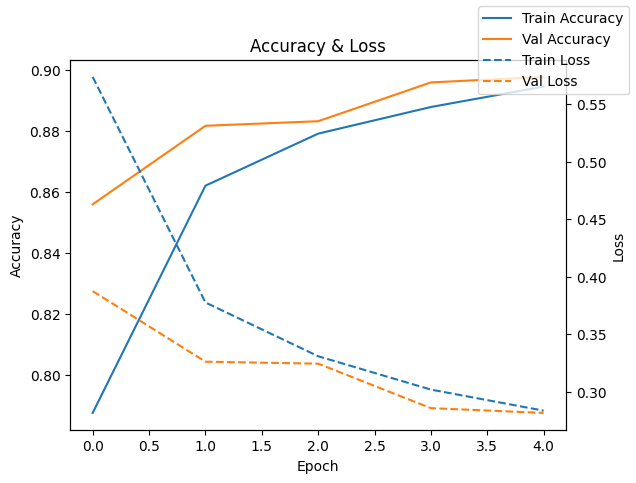

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax2 = ax1.twinx()
ax2.plot(history.history['loss'], linestyle='dashed', label='Train Loss')
ax2.plot(history.history['val_loss'], linestyle='dashed', label='Val Loss')
ax2.set_ylabel('Loss')

plt.title('Accuracy & Loss')

fig.legend(loc='upper right')
plt.show()

In [ ]:
import os

In [ ]:
from tensorflow.keras.models import load_model
model.save('model.h5')
model = load_model('model.h5')

In [ ]:
!ls

data  model.pth  sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image_0.png to image_0 (2).png
Saving image_1.png to image_1 (1).png
Saving image_2.png to image_2 (1).png
Saving image_3.png to image_3 (1).png
Saving image_4.png to image_4 (1).png


In [ ]:
file_name = list(uploaded.keys())[0]

In [ ]:
from PIL import Image

img = Image.open(file_name).convert('L')

In [ ]:

img = img.resize((28, 28))
img = np.array(img)

# invert colors (VERY IMPORTANT sometimes)
img = 255 - img

img = img / 255.0
img = img.reshape(1, 28, 28, 1)

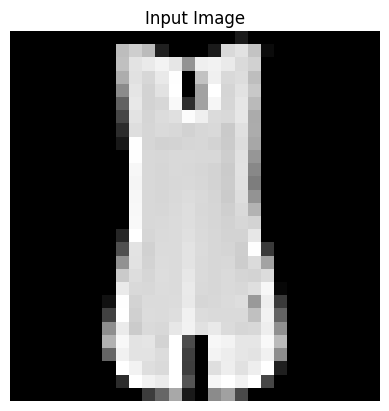

In [ ]:
file_name = list(uploaded.keys())[0]

img = Image.open(file_name).convert('L')
img = img.resize((28, 28))

plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

img_array = np.array(img) / 255.0
img_array = img_array.reshape(1, 28, 28, 1)

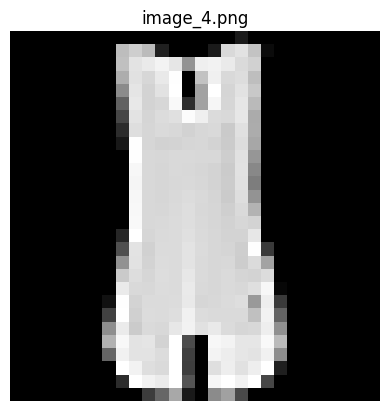

AttributeError: 'FashionCNN' object has no attribute 'predict'

In [ ]:
for file_name in uploaded.keys():

    img = Image.open(file_name).convert('L')
    img = img.resize((28, 28))

    plt.imshow(img, cmap='gray')
    plt.title(file_name)
    plt.axis('off')
    plt.show()

    img_array = np.array(img) / 255.0
    img_array = 1 - img_array
    img_array = img_array.reshape(1, 28, 28, 1)

    prediction = model.predict(img_array)
    print("Prediction:", np.argmax(prediction))

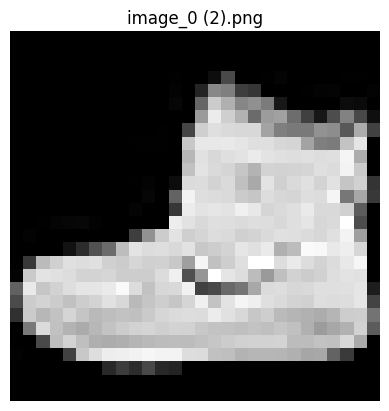

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
image_0 (2).png → Bag
----------------------------------------


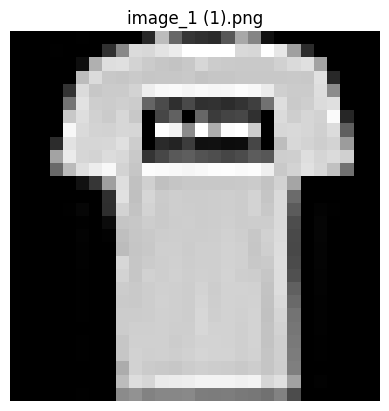

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
image_1 (1).png → Pullover
----------------------------------------


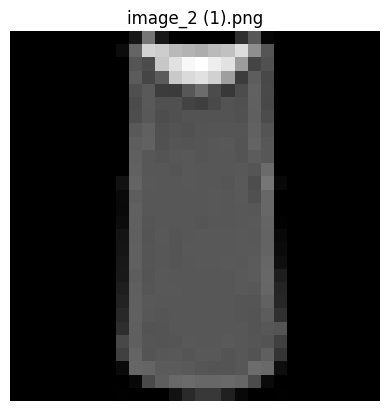

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
image_2 (1).png → Sandal
----------------------------------------


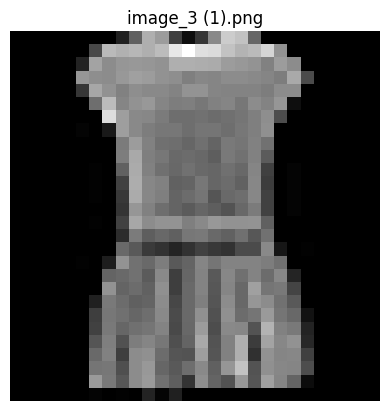

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
image_3 (1).png → Sandal
----------------------------------------


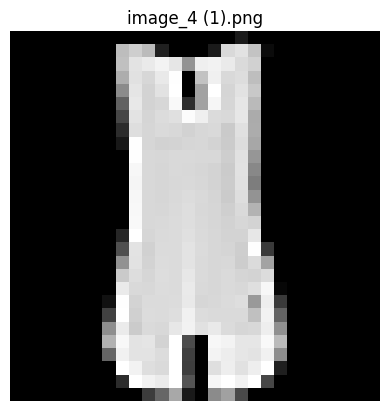

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
image_4 (1).png → Sandal
----------------------------------------


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Shirt", "Sandal", "Sneaker", "Bag", "Ankle boot"
]

for file_name in uploaded.keys():

    # Load image
    img = Image.open(file_name).convert('L')
    img = img.resize((28, 28))

    # Show image
    plt.imshow(img, cmap='gray')
    plt.title(file_name)
    plt.axis('off')
    plt.show()

    # Preprocess
    img_array = np.array(img) / 255.0
    img_array = 1 - img_array   # 🔥 important
    img_array = img_array.reshape(1, 28, 28, 1)

    # Predict
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)

    # Print result
    print(f"{file_name} → {class_names[predicted_class]}")
    print("-" * 40)

In [ ]:
prediction

array([[2.3161967e-03, 1.1891259e-04, 6.4716965e-02, 3.5235712e-03,
        1.3713396e-02, 5.1077370e-07, 9.1543651e-01, 8.7655842e-08,
        1.7257828e-04, 1.3449165e-06]], dtype=float32)

SAME PROBLEM IN PYTORCH


In [ ]:
import random
import numpy as np
import torch

random.seed(0)

np.random.seed(0)

torch.manual_seed(0)

# torch.cuda.manual_seed(0)
# torch.cuda.manual_seed_all(0)

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [ ]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([ transforms.ToTensor()  # converts to tensor + normalizes (0–1)
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST( root='./data', train=False, download=True, transform=transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.8MB/s]


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# import matplotlib.pyplot as plt

# img_tensor, label = train_dataset[7]

# plt.imshow(img_tensor.squeeze(), cmap='gray')
# plt.title(label)  # label number
# plt.axis('off')
# plt.show()

In [ ]:
# class_names = [
#     "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
#     "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
# ]

# plt.title(class_names[label])

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()


        self.conv1 = nn.Conv2d(1, 32, 3)   # (1,28,28) → (32,26,26)
        self.pool = nn.MaxPool2d(2, 2)     # → (32,13,13)

        self.conv2 = nn.Conv2d(32, 64, 3)  # → (64,11,11)
        # pool → (64,5,5)

        self.conv3 = nn.Conv2d(64, 64, 3)  # → (64,3,3)

        self.dropout = nn.Dropout(0.5)


        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = F.relu(self.conv3(x))

        x = self.dropout(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FashionCNN(nn.Module):

    def __init__(self):
        super(FashionCNN, self).__init__()


        self.conv1 = nn.Conv2d(1, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 64, 3)


        self.dropout = nn.Dropout(0.25)


        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = F.relu(self.conv3(x))

        x = self.dropout(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [ ]:
model = FashionCNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import torch.nn as nn
import torch.optim as optim


model = FashionCNN()


criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

In [ ]:
transform = transforms.ToTensor()

In [ ]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST( root='./data', train=False, download=True transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.38MB/s]


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:


epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()


        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total


    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/5 | Train Acc: 0.7624 | Val Acc: 0.8390
Epoch 2/5 | Train Acc: 0.8446 | Val Acc: 0.8718
Epoch 3/5 | Train Acc: 0.8677 | Val Acc: 0.8858
Epoch 4/5 | Train Acc: 0.8794 | Val Acc: 0.8864
Epoch 5/5 | Train Acc: 0.8881 | Val Acc: 0.8905


In [ ]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = correct / total

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Test Accuracy: 0.8905
Test Loss: 91.46069236844778


In [ ]:
import torch

torch.save(model.state_dict(), 'model.pth')

In [ ]:
model = FashionCNN()
model.load_state_dict(torch.load('model.pth'))
model.eval()

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=576, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image_4.png to image_4.png


In [ ]:
from PIL import Image

img = Image.open(file_name).convert('L')

In [ ]:

img = img.resize((28, 28))
img = np.array(img)

img = 255 - img

img = img / 255.0
img = img.reshape(1, 28, 28, 1)

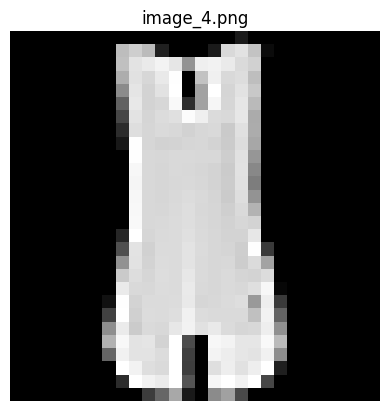

image_4.png → Sandal
----------------------------------------


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()

class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Shirt", "Sandal", "Sneaker", "Bag", "Ankle boot"
]

for file_name in uploaded.keys():

    img = Image.open(file_name).convert('L')
    img = img.resize((28, 28))

    plt.imshow(img, cmap='gray')
    plt.title(file_name)
    plt.axis('off')
    plt.show()


    img_array = np.array(img) / 255.0
    img_array = 1 - img_array

    img_tensor = torch.tensor(img_array, dtype=torch.float32)
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
    # shape → (1, 1, 28, 28)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)

    print(f"{file_name} → {class_names[predicted.item()]}")
    print("-" * 40)

This is new Project 02-05-2026

In [ ]:
!apt-get install -y portaudio19-dev
!pip install pyaudio

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
Suggested packages:
  libasound2-doc jackd1 portaudio19-doc
The following packages will be REMOVED:
  libjack-jackd2-0
The following NEW packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
  portaudio19-dev
0 upgraded, 6 newly installed, 1 to remove and 42 not upgraded.
Need to get 596 kB of archives.
After this operation, 3,178 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack0 amd64 1:0.125.0-3build2 [93.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libasound2-dev amd64 1.2.6.1-1ubuntu1.1 [110 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack-dev amd64 1:0.125.0-3build2 [206 kB]
Get:4 http://archive.ubuntu.com/ubuntu jam

In [ ]:
import pyaudio

PyAudio installed successfully


In [ ]:
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

In [ ]:
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Successfully uninstalled click-8.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [ ]:
from gtts import gTTS

In [ ]:
from gtts import gTTS

text = "Hello How are you?"

tts = gTTS(text=text, lang="en")

tts.save("voice.mp3")

In [ ]:
from IPython.display import Audio

Audio("voice.mp3")

In [ ]:
from google.colab import files

files.download("voice.mp3")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 97.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 14.2 MB/s eta 0:00:00
  Created wheel for encodec: filename=encodec-0.1.1-py3-none-any.whl size=45759 sha256=d204447f75a2e825d713b03b1c0cdb1462c6dc19959532d361c23200054a9268
  Stored in directory: /root/.cache/pip/wheels/b8/eb/9f/e13610cc46ab39d3199fbabebd1c3e142d44b679526e0f228a
Successfully built encodec
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
ERROR: pip's dependency resolver does not curre

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


text_2.pt:   0%|          | 0.00/5.35G [00:00<?, ?B/s]

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mor

In [ ]:
from IPython.display import Audio
Audio("whitebeard_style.wav")

ValueError: rate must be specified when data is a numpy array or list of audio samples.

In [ ]:
from gtts import gTTS
from IPython.display import Audio

text = "नमस्ते, आप कैसे हैं"

tts = gTTS(text=text, lang="hi")

tts.save("hindi_voice.mp3")

Audio("hindi_voice.mp3")

In [ ]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.9 MB/s eta 0:00:00


In [ ]:
from deep_translator import GoogleTranslator

text = "Hello, how are you?"

translated = GoogleTranslator(source='en', target='hi').translate(text)

print(translated)

नमस्ते, आप कैसे हैं?


In [ ]:
!apt-get install -y portaudio19-dev
!pip install SpeechRecognition PyAudio deep-translator gTTS

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.6.0-1.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 27.4 MB/s eta 0:00:00
Using cached click-8.1.8-py3-none-any.whl (98 kB)
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Successfully uninstalled click-8.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [ ]:
!pip install deep-translator gTTS SpeechRecognition

In [ ]:
import speech_recognition as sr
from deep_translator import GoogleTranslator
from gtts import gTTS
from IPython.display import Audio

recognizer = sr.Recognizer()

with sr.Microphone() as source:
  print("Speak in English...")
  recognizer.adjust_for_ambient_noise(source)
  audio_data = recognizer.listen(source)

try:

    english_text = recognizer.recognize_google(audio_data)

    print("You said", english_text)
    hindi_text = GoogleTranslator(source='en', target='hi').translate(english_text)

    print("Hindi", hindi_text)
    tts = gTTS(text=hindi_text, lang='hi')

    tts.save("translated_hindi.mp3")
    display(Audio("translated_hindi.mp3", autoplay=True))
except Exception as e:
    print("Error", e)

OSError: No Default Input Device Available

In [ ]:
from IPython.display import Javascript
from google.colab import output

output.eval_js("""
navigator.mediaDevices.getUserMedia({audio:true})
""")

MessageError: DataCloneError: Failed to execute 'postMessage' on 'MessagePort': MediaStream object could not be cloned.

In [ ]:
import speech_recognition as sr
from deep_translator import GoogleTranslator
from gtts import gTTS
from IPython.display import Javascript, Audio, display
from google.colab import output
from base64 import b64decode
from pydub import AudioSegment

# Record audio
RECORD = """
async function recordAudio() {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true });

  const recorder = new MediaRecorder(stream);

  const chunks = [];

  recorder.ondataavailable = e => chunks.push(e.data);

  recorder.start();

  await new Promise(resolve => setTimeout(resolve, 10000));

  recorder.stop();

  await new Promise(resolve => recorder.onstop = resolve);

  const blob = new Blob(chunks);

  const reader = new FileReader();

  reader.readAsDataURL(blob);

  return await new Promise(resolve => {
    reader.onloadend = () => resolve(reader.result);
  });
}

recordAudio();
"""

print("Speak now...")

audio_string = output.eval_js(RECORD)

audio_data = b64decode(audio_string.split(',')[1])

# Save as webm
with open("input.webm", "wb") as f:
    f.write(audio_data)

# Convert webm to wav
audio = AudioSegment.from_file("input.webm")

audio.export("input.wav", format="wav")

# Speech recognition
recognizer = sr.Recognizer()

with sr.AudioFile("input.wav") as source:
    audio_data = recognizer.record(source)

try:
    english_text = recognizer.recognize_google(audio_data)

    print("You said:", english_text)

    hindi_text = GoogleTranslator(source='en', target='hi').translate(english_text)

    print("Hindi:", hindi_text)

    tts = gTTS(text=hindi_text, lang='hi')

    tts.save("translated_hindi.mp3")

    display(Audio("translated_hindi.mp3", autoplay=True))

except sr.UnknownValueError:
    print("Could not understand audio")

except sr.RequestError as e:
    print("Google API Error:", e)

except Exception as e:
    print("Full Error:", repr(e))

except Exception as e:
    print("Error:", e)

Speak now...
Could not understand audio
